In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
print("Imports Done!")

Imports Done!


# Step 1 - Profiling
1. import the "Titanic" dataset using seaborn as a data frame
2. Store the df as a csv
3. show info(), describe() and shape on this data set
4. compute percentage of missing values in columns that have any

In [2]:
# import titanic data set from seaborn
titanic_df = sns.load_dataset("titanic")
titanic_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [3]:
# save it as a .csv file
titanic_df.to_csv(path_or_buf = 'titanic_raw.csv', mode = 'w', index = False)

In [4]:
# show shape, info and describe
print(f"The shape of the titanic data frame - {titanic_df.shape}")
print("-" * 20)
print("Data Frame Info:\n")
print(titanic_df.info())
print("-" * 20)
print("data frame describe():\n")
print(titanic_df.describe())
print("-" * 20)

The shape of the titanic data frame - (891, 15)
--------------------
Data Frame Info:

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None
--

In [5]:
# show % of null values in the data set
df_len = len(titanic_df)
print(f"{"Column":<15}{"% null values"}")
print("-" * 30)
for column in titanic_df.columns:
    percent_null_values = (titanic_df[column].isna().sum() / df_len) * 100
    print(f"{column:<15}{percent_null_values:.2f}")

Column         % null values
------------------------------
survived       0.00
pclass         0.00
sex            0.00
age            19.87
sibsp          0.00
parch          0.00
fare           0.00
embarked       0.22
class          0.00
who            0.00
adult_male     0.00
deck           77.22
embark_town    0.22
alive          0.00
alone          0.00


# Step 2 - Cleaning
1. drop columns containing duplicated information -> Feature Elimination
    - class - as its just a text description of pclass column
    - who - as it is just a description of sex column
    - adult_male - as it is just a derived column from sex and age columns
    - embark_town - as its a description to the embarked column
    - alone - its just a derived column from sibsp and parch
2. Handle missing values
    - age -> as there are ~20% missing values impute these missing values using strategy as median
    - embarked -> as only 0.22 % of rows have missing values remove the rows entirely
    - deck -> as > 70 % values are missing remove the feature entirely

In [6]:
# drop the unessary columns
columns_to_be_dropped = [
    "class",
    "who",
    "adult_male",
    "embark_town",
    "alone"
]
titanic_df.drop(columns = columns_to_be_dropped, inplace = True)
print(f"Columns {columns_to_be_dropped} are dropped from the data frame")
print("info() after dropping unnessasary columns")
print("-" * 20)
print(titanic_df.info())
print("-" * 20)

Columns ['class', 'who', 'adult_male', 'embark_town', 'alone'] are dropped from the data frame
info() after dropping unnessasary columns
--------------------
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   survived  891 non-null    int64   
 1   pclass    891 non-null    int64   
 2   sex       891 non-null    str     
 3   age       714 non-null    float64 
 4   sibsp     891 non-null    int64   
 5   parch     891 non-null    int64   
 6   fare      891 non-null    float64 
 7   embarked  889 non-null    str     
 8   deck      203 non-null    category
 9   alive     891 non-null    str     
dtypes: category(1), float64(2), int64(4), str(3)
memory usage: 64.0 KB
None
--------------------


In [7]:
# impute age
titanic_df["age"] = titanic_df["age"].fillna(titanic_df["age"].median())

# handle the embarked column
titanic_df.dropna(subset = ["embarked"])

# remove deck column
titanic_df.drop(columns = ["deck"], inplace = True)

print(f"Columns age, embarked and deck are handled for missing values")
print("info() after handling missing values")
print("-" * 20)
print(titanic_df.info())
print("-" * 20)

Columns age, embarked and deck are handled for missing values
info() after handling missing values
--------------------
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       891 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    str    
 8   alive     891 non-null    str    
dtypes: float64(2), int64(4), str(3)
memory usage: 62.8 KB
None
--------------------


# Step 3 - Univariate Analysis
1. plot hist and box plots for age and fare columns
2. report number of outliers in age and fare columns
3. compute mean, median and mode for fare column

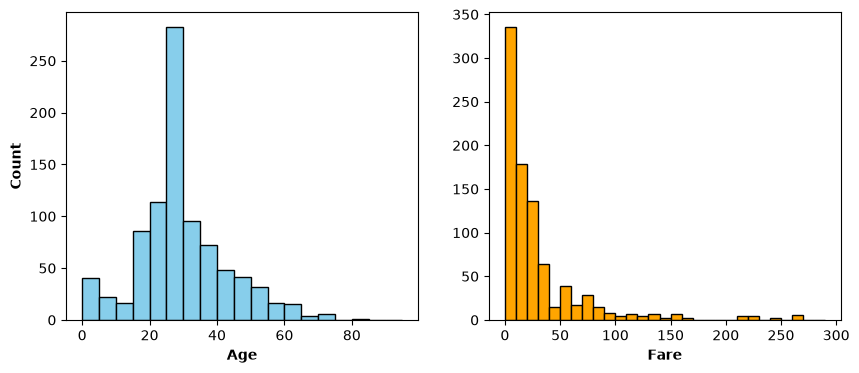

In [18]:
# plot histograms on age and fare columns

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
bins_for_age = np.arange(0, 100, 5)
bins_for_fare = np.arange(0, 300, 10)

ax1.hist(titanic_df["age"], bins=bins_for_age, color="skyblue", edgecolor="black")
ax1.set_xlabel("Age", fontweight="bold")
ax1.set_ylabel("Count", fontweight="bold")

ax2.hist(titanic_df["fare"], bins=bins_for_fare, color="orange", edgecolor="black")
ax2.set_xlabel("Fare", fontweight="bold")
# ax2.set_ylabel("Count")

plt.show()


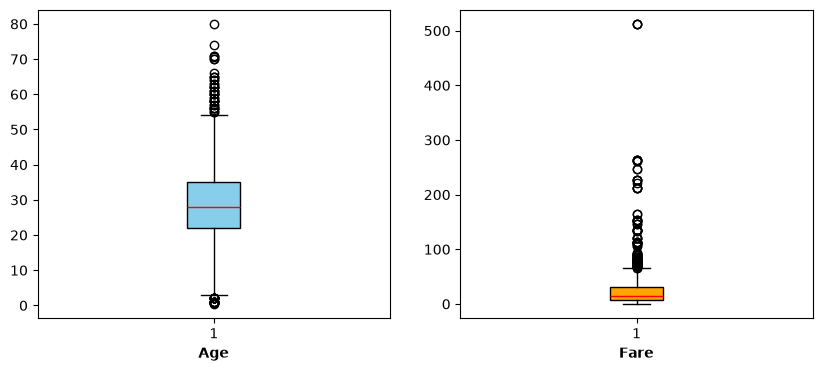

The outliers in age data are - None
The outliers in fare data are - None


In [ ]:
# plot bos plots for age and fare columns

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

age_plot = ax1.boxplot(titanic_df["age"], patch_artist=True, 
           boxprops=dict(facecolor='skyblue', color='black'),
           medianprops=dict(color='red'))
ax1.set_xlabel("Age", fontweight="bold")

fare_plot = ax2.boxplot(titanic_df["fare"], patch_artist=True, 
           boxprops=dict(facecolor='orange', color='black'),
           medianprops=dict(color='red'))
ax2.set_xlabel("Fare", fontweight="bold")

plt.show()

In [41]:
# Outliers in fare and age columns
age_outliers = [float(i) for i in age_plot["fliers"][0].get_ydata()]
fare_outliers = [float(i) for i in fare_plot["fliers"][0].get_ydata()]
age_outliers.sort()
fare_outliers.sort()
print(f"The outliers in age data are - {age_outliers}")
print(f"The outliers in fare data are - {fare_outliers}")
print("Analysis: All the ages <= 2 years and >= 55 years are ouliers")
print(f"Analysis: All the fares >= 66.6 bucks are outliers")

The outliers in age data are - [0.42, 0.67, 0.75, 0.75, 0.83, 0.83, 0.92, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 55.0, 55.0, 55.5, 56.0, 56.0, 56.0, 56.0, 57.0, 57.0, 58.0, 58.0, 58.0, 58.0, 58.0, 59.0, 59.0, 60.0, 60.0, 60.0, 60.0, 61.0, 61.0, 61.0, 62.0, 62.0, 62.0, 62.0, 63.0, 63.0, 64.0, 64.0, 65.0, 65.0, 65.0, 66.0, 70.0, 70.0, 70.5, 71.0, 71.0, 74.0, 80.0]
The outliers in fare data are - [66.6, 66.6, 69.3, 69.3, 69.55, 69.55, 69.55, 69.55, 69.55, 69.55, 69.55, 71.0, 71.0, 71.2833, 73.5, 73.5, 73.5, 73.5, 73.5, 75.25, 76.2917, 76.7292, 76.7292, 76.7292, 77.2875, 77.2875, 77.9583, 77.9583, 77.9583, 78.2667, 78.2667, 78.85, 78.85, 79.2, 79.2, 79.2, 79.2, 79.65, 79.65, 79.65, 80.0, 80.0, 81.8583, 82.1708, 82.1708, 83.1583, 83.1583, 83.1583, 83.475, 83.475, 86.5, 86.5, 86.5, 89.1042, 89.1042, 90.0, 90.0, 90.0, 90.0, 91.0792, 91.0792, 93.5, 93.5, 106.425, 106.425, 108.9, 108.9, 110.8833, 110.8833, 110.8833, 110.8833, 113.275, 113.275, 113.2

In [52]:
# calculate mean, median and mode for age and fare columns
age_mean = float(titanic_df["age"].mean()).__round__(2)
age_median = float(titanic_df["age"].median()).__round__(2)
age_mode = float(titanic_df["age"].mode()[0]).__round__(2)

fare_mean = float(titanic_df["fare"].mean()).__round__(2)
fare_median = float(titanic_df["fare"].median()).__round__(2)
fare_mode = float(titanic_df["fare"].mode()[0]).__round__(2)

print(f"{"column":<10}{"Mean":<10}{"Median":<10}{"Mode":<10}")
print("-" * 40)
print(f"{"Age":<10}{age_mean:<10}{age_median:<10}{age_mode:<10}")
print(f"{"Fare":<10}{fare_mean:<10}{fare_median:<10}{fare_mode:<10}")

column    Mean      Median    Mode      
----------------------------------------
Age       29.36     28.0      28.0      
Fare      32.2      14.45     8.05      


__Skweness of age and fare columns__
- for `age` column as Mean > Median = Mode -> long tail extends towards right but as difference between mean and median is not so large, the distribution can be said as __moderately right-skewed__
- for `fare` column as Mean > Median > Mode -> long tail extends towards right but as difference between mean and median and mode is large, the distribution can be said as __highly right-skewed__